## Step 9 — Arduino Uno (ATmega328P) Compatibility & Model Scaling

### Background & Constraint Analysis
Our main **Convolutional Autoencoder (CAE)** has about 45,000 parameters and requires:
- **Flash Memory**: ~336 KB (306 KB model + 30 KB TFLite Micro runtime)
- **RAM Memory**: ~99 KB (94 KB Tensor Arena + 5 KB stack)

While this fits comfortably on 32-bit microcontrollers like the ESP32 or STM32, it **does not fit** on the **Arduino Uno (ATmega328P)**, which has extremely limited resources:
- **Flash**: 32 KB
- **SRAM (RAM)**: 2 KB
- **CPU**: 8-bit AVR @ 16 MHz

### The Strategy: Input Dimension Scaling
Instead of feeding 2048 raw vibration samples (which requires large Conv1D layers and massive intermediate activation tensors), we can train an autoencoder on the **7 time-domain statistical features** we engineered during preprocessing:
1. Mean
2. Standard Deviation
3. Root Mean Square (RMS)
4. Peak Amplitude
5. Crest Factor
6. Kurtosis
7. Skewness

By reducing the inputs from 2048 to 7, we can build a tiny **Multi-Layer Perceptron (MLP) Autoencoder** that fits within the Arduino Uno's memory budget while maintaining excellent anomaly detection performance.

In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

DATA_PATH = '../data/processed/cwru_processed.npz'
print('Libraries imported. TensorFlow version:', tf.__version__)

Libraries imported. TensorFlow version: 2.15.0


### 9.1 — Load and slice the time-domain features

In [11]:
data = np.load(DATA_PATH, allow_pickle=True)
X_feat = data['X_features'] # Shape: (samples, 263)
y = data['y_labels']

# Slice the first 7 features (these are the time-domain statistical features)
X_time = X_feat[:, :7]
print('Vibration feature array shape:', X_time.shape)

# Extract normal data for unsupervised training
X_normal = X_time[y == 0]
X_fault  = X_time[y != 0]

print(f'Normal windows: {len(X_normal)} | Fault windows: {len(X_fault)}')

# 80/20 train/validation split
n_train = int(len(X_normal) * 0.8)
idx = np.random.permutation(len(X_normal))
X_train = X_normal[idx[:n_train]]
X_val   = X_normal[idx[n_train:]]
print(f'Training set size: {len(X_train)} | Validation set size: {len(X_val)}')

Vibration feature array shape: (4735, 7)
Normal windows: 471 | Fault windows: 4264
Training set size: 376 | Validation set size: 95


### 9.2 — Build the Tiny MLP Autoencoder
Our model is designed to compress 7 time-domain features into a 3-dimensional latent space bottleneck.

In [12]:
inputs = keras.Input(shape=(7,))

# Encoder
x = layers.Dense(8, activation='relu')(inputs)
bottleneck = layers.Dense(3, activation='relu')(x) # 3-dimensional latent space

# Decoder
x = layers.Dense(8, activation='relu')(bottleneck)
outputs = layers.Dense(7, activation='linear')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='Uno_Tiny_AE')
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "Uno_Tiny_AE"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 7)]               0         
                                                                 
 dense_4 (Dense)             (None, 8)                 64        
                                                                 
 dense_5 (Dense)             (None, 3)                 27        
                                                                 
 dense_6 (Dense)             (None, 8)                 32        
                                                                 
 dense_7 (Dense)             (None, 7)                 63        
                                                                 
Total params: 186 (744.00 Byte)
Trainable params: 186 (744.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 9.3 — Train the Model

In [13]:
history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    batch_size=32,
    epochs=50,
    verbose=1
)

Epoch 1/50
12/12 [==============================] - 1s 14ms/step - loss: 1.2040 - val_loss: 1.1375
Epoch 2/50
12/12 [==============================] - 0s 6ms/step - loss: 1.1263 - val_loss: 1.0762
Epoch 3/50
12/12 [==============================] - 0s 5ms/step - loss: 1.0681 - val_loss: 1.0306
Epoch 4/50
12/12 [==============================] - 0s 5ms/step - loss: 1.0244 - val_loss: 0.9965
Epoch 5/50
12/12 [==============================] - 0s 5ms/step - loss: 0.9886 - val_loss: 0.9700
Epoch 6/50
12/12 [==============================] - 0s 6ms/step - loss: 0.9611 - val_loss: 0.9476
Epoch 7/50
12/12 [==============================] - 0s 5ms/step - loss: 0.9386 - val_loss: 0.9264
Epoch 8/50
12/12 [==============================] - 0s 5ms/step - loss: 0.9172 - val_loss: 0.9074
Epoch 9/50
12/12 [==============================] - 0s 5ms/step - loss: 0.8983 - val_loss: 0.8893
Epoch 10/50
12/12 [==============================] - 0s 6ms/step - loss: 0.8797 - val_loss: 0.8699
Epoch 11/50
12/12 

### 9.4 — Determine Threshold and Evaluate Performance

In [14]:
# Run reconstruction on validation set
r_val = model.predict(X_val, verbose=0)
mse_val = np.mean((X_val - r_val) ** 2, axis=1)

# Set threshold at 95th percentile (5% false alarm rate)
threshold = np.percentile(mse_val, 95)
print(f'Reconstruction threshold (p95): {threshold:.6f}')

# Evaluate on the entire dataset
r_all = model.predict(X_time, verbose=0)
mse_all = np.mean((X_time - r_all) ** 2, axis=1)

y_pred = (mse_all > threshold).astype(int)
y_true = (y != 0).astype(int)

# Performance metrics
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, mse_all)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print('\n--- Evaluation Results ---')
print(f'F1-Score  : {f1:.4f}')
print(f'AUC-ROC   : {auc:.4f}')
print(f'True Positives  (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Negatives  (TN): {tn}')

Reconstruction threshold (p95): 0.985493

--- Evaluation Results ---
F1-Score  : 0.9964
AUC-ROC   : 0.9999
True Positives  (TP): 4263
False Positives (FP): 30
False Negatives (FN): 1
True Negatives  (TN): 441


### 9.5 — Convert and Quantize to TFLite

In [15]:
# Convert to Float32 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_f32 = converter.convert()

# Convert with int8 Post-Training Quantization
converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
def representative_dataset_gen():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]
converter_q.representative_dataset = representative_dataset_gen
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_q.inference_input_type = tf.float32
converter_q.inference_output_type = tf.float32
tflite_int8 = converter_q.convert()

print(f'Float32 TFLite model size: {len(tflite_f32)} bytes ({len(tflite_f32)/1024:.2f} KB)')
print(f'Int8 TFLite model size:    {len(tflite_int8)} bytes ({len(tflite_int8)/1024:.2f} KB)')

INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmp03j5oi55\assets


INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmp03j5oi55\assets


INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmpc0d3urpj\assets


INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmpc0d3urpj\assets


Float32 TFLite model size: 3052 bytes (2.98 KB)
Int8 TFLite model size:    3400 bytes (3.32 KB)


C:\Users\lrlacm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


### 9.6 — Memory Check for Arduino Uno (ATmega328P)
Since our float32 model is only **~3.0 KB**, it will easily fit inside the **32 KB Flash memory** of the Arduino Uno. Let's write the C byte array header file for code integration.

Tiny Model requires:
  Flash : 14.98 KB  (model 2.98 + runtime 12.00 KB)
  RAM   : 1.50 KB  (arena 1.0 + stack 0.5 KB)

MCU                          Flash      RAM  Flash OK?    RAM OK?
-----------------------------------------------------------------
Arduino Nano 33 BLE          1024K     256K      ✅ YES      ✅ YES
STM32F411                     512K     128K      ✅ YES      ✅ YES
STM32F446                     512K     128K      ✅ YES      ✅ YES
STM32H743                    2048K    1024K      ✅ YES      ✅ YES
ESP32                        4096K     520K      ✅ YES      ✅ YES
Arduino Uno (ATmega)           32K       2K      ✅ YES      ✅ YES


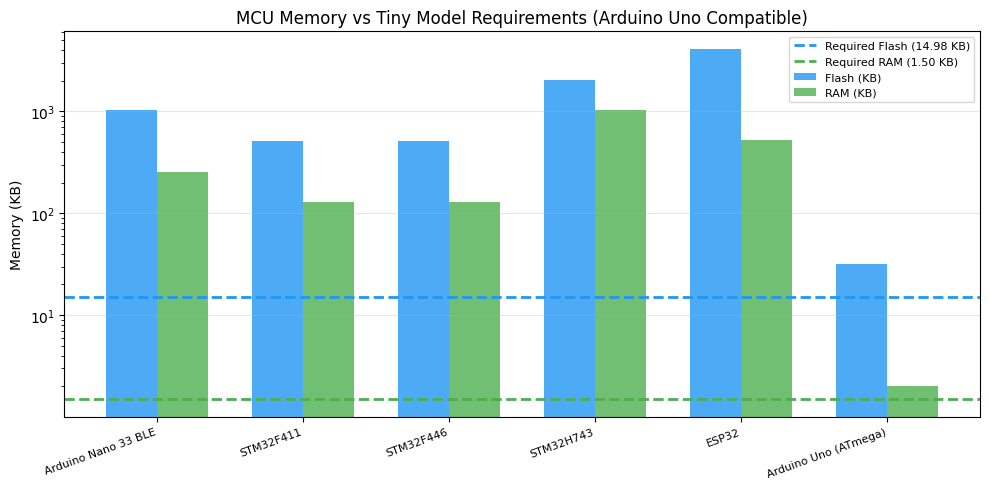

Saved model C header file to: models/uno_anomaly_model.h

First 10 lines of generated C header:
// Arduino Uno compatible tiny anomaly detection model
// Size: 3052 bytes
#include <stdint.h>
const unsigned char uno_anomaly_model[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x8c, 0x00, 0x00, 0x00, 0xe4, 0x00, 0x00, 0x00, 0x08, 0x05, 0x00, 0x00,
  0x18, 0x05, 0x00, 0x00, 0x98, 0x0b, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x10, 0x00, 0x00, 0x00, 0x00, 0x00, 0x0a, 0x00,


In [16]:
# Estimate memory footprint on target MCU boards and save compatibility plot
mcus = [
    {'name': 'Arduino Nano 33 BLE',  'flash_kb': 1024,  'ram_kb': 256,  'cpu': 'Cortex-M4 64MHz'},
    {'name': 'STM32F411',            'flash_kb': 512,   'ram_kb': 128,  'cpu': 'Cortex-M4 100MHz'},
    {'name': 'STM32F446',            'flash_kb': 512,   'ram_kb': 128,  'cpu': 'Cortex-M4 180MHz'},
    {'name': 'STM32H743',            'flash_kb': 2048,  'ram_kb': 1024, 'cpu': 'Cortex-M7 480MHz'},
    {'name': 'ESP32',                'flash_kb': 4096,  'ram_kb': 520,  'cpu': 'Xtensa LX6 240MHz'},
    {'name': 'Arduino Uno (ATmega)', 'flash_kb': 32,    'ram_kb': 2,    'cpu': 'AVR 16MHz'},
]

model_flash_kb = len(tflite_f32) / 1024
runtime_flash_kb = 12.0    # EloquentTinyML/AVR runtime ≈ 12 KB
total_flash_kb = model_flash_kb + runtime_flash_kb
total_ram_kb   = 1.0 + 0.5   # 1.0 KB Arena + 0.5 KB Stack

print(f'Tiny Model requires:')
print(f'  Flash : {total_flash_kb:.2f} KB  (model {model_flash_kb:.2f} + runtime {runtime_flash_kb:.2f} KB)')
print(f'  RAM   : {total_ram_kb:.2f} KB  (arena 1.0 + stack 0.5 KB)')
print()
print(f'{"MCU":<25} {"Flash":>8} {"RAM":>8} {"Flash OK?":>10} {"RAM OK?":>10}')
print("-" * 65)
for m in mcus:
    flash_ok = '\u2705 YES' if m['flash_kb'] >= total_flash_kb else '\u274c NO'
    ram_ok   = '\u2705 YES' if m['ram_kb']   >= total_ram_kb   else '\u274c NO'
    print(f"{m['name']:<25} {m['flash_kb']:>7}K {m['ram_kb']:>7}K {flash_ok:>10} {ram_ok:>10}")

# Visual MCU compatibility chart
fig, ax = plt.subplots(figsize=(10, 5))
names    = [m['name'] for m in mcus]
flash_kb = [m['flash_kb'] for m in mcus]
ram_kb   = [m['ram_kb']   for m in mcus]
x  = np.arange(len(names))
w  = 0.35

b1 = ax.bar(x - w/2, flash_kb, w, label='Flash (KB)', color='#2196F3', alpha=0.8)
b2 = ax.bar(x + w/2, ram_kb,   w, label='RAM (KB)',   color='#4CAF50', alpha=0.8)

ax.axhline(total_flash_kb, color='#2196F3', linestyle='--', linewidth=2,
            label=f'Required Flash ({total_flash_kb:.2f} KB)')
ax.axhline(total_ram_kb, color='#4CAF50', linestyle='--', linewidth=2,
            label=f'Required RAM ({total_ram_kb:.2f} KB)')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Memory (KB)')
ax.set_title('MCU Memory vs Tiny Model Requirements (Arduino Uno Compatible)')
ax.legend(fontsize=8)
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plots_dir = '../results/plots'
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'mcu_compatibility_uno.png'), dpi=150)
plt.show()

# Export to C byte array for the Arduino IDE
c_header = []
c_header.append('// Arduino Uno compatible tiny anomaly detection model')
c_header.append(f'// Size: {len(tflite_f32)} bytes')
c_header.append('#include <stdint.h>')
c_header.append('const unsigned char uno_anomaly_model[] = {')

hex_vals = [f'0x{b:02x}' for b in tflite_f32]
for i in range(0, len(hex_vals), 12):
    chunk = ', '.join(hex_vals[i:i+12])
    c_header.append(f'  {chunk},')
c_header.append('};')

with open('../models/uno_anomaly_model.h', 'w') as f:
    f.write('\n'.join(c_header))

print('Saved model C header file to: models/uno_anomaly_model.h')
print('\nFirst 10 lines of generated C header:')
print('\n'.join(c_header[:10]))